In [9]:
import numpy as np 
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error, r2_score 
import matplotlib.pyplot as plt 


In [2]:
x = np.array([[1],[2] , [3],[4]])
y = np.array([2, 4, 6, 8])

In [3]:
#Linear Regression
#===========================
lin_reg = LinearRegression()
lin_reg.fit(x,y)
y_pred_lin = lin_reg.predict(x)
#===============================
#Ridge Regression with small alpha
#=================================
ridge = Ridge(alpha=1.0)
ridge.fit(x,y)
y_pred_ridge = ridge.predict(x)
#===============================
#Lasso Regression with large alpha
#=================================
lasso = Lasso(alpha=10 )
lasso.fit(x,y)
y_pred_lasso = lasso.predict(x)
#==============================
print("LinearRegression")
print("MSE:", mean_squared_error(y, y_pred_lin))
print("b:", lin_reg.intercept_)
print("W:", lin_reg.coef_)
print("=======================================")
print("Ridge Regression")
print("MSE:", mean_squared_error(y, y_pred_ridge))
print("b:", ridge.intercept_)
print("W:", ridge.coef_)
print("=======================================")
print("Lasso Regression")
print("MSE:", mean_squared_error(y, y_pred_lasso))
print("b:", lasso.intercept_)
print("W:", lasso.coef_)
print("=======================================")

LinearRegression
MSE: 0.0
b: 0.0
W: [2.]
Ridge Regression
MSE: 0.13888888888888887
b: 0.833333333333333
W: [1.66666667]
Lasso Regression
MSE: 5.0
b: 5.0
W: [0.]


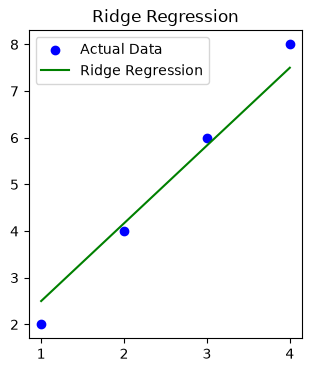

In [4]:
#Ridge Regression 
plt.figure(figsize=(12,4))
plt.subplot(1,3,2)
plt.scatter(x,y, color = "b" , label = "Actual Data")
plt.plot(x, y_pred_ridge, color = "green", label = "Ridge Regression")
plt.title("Ridge Regression")
plt.legend()
plt.show()

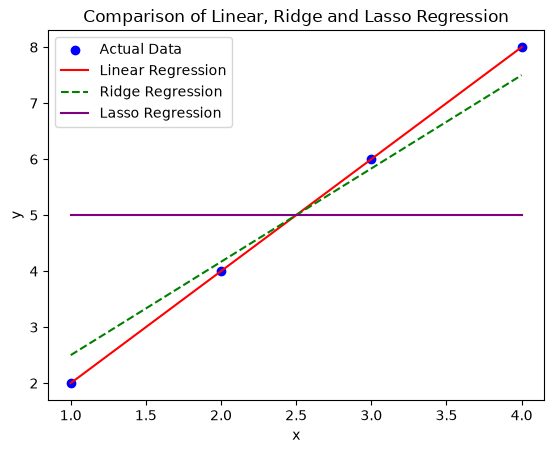

In [5]:
plt.scatter(x,y, color = "b" , label = "Actual Data")
plt.plot(x, y_pred_lin, color = "red", label = "Linear Regression")
plt.plot(x, y_pred_ridge, color = "green", linestyle='--' , label = "Ridge Regression")
plt.plot(x, y_pred_lasso, color = "purple", label = "Lasso Regression")
plt.title("Comparison of Linear, Ridge and Lasso Regression")
plt.xlabel("x")
plt.ylabel('y')
plt.legend()
plt.show()

In [8]:
data = pd.read_csv("Salary_Data.csv")

c:\Users\shahd\Desktop\DEPI_AI\DEPI-AMIT-R5-AI\.venv\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


<Figure size 300x300 with 0 Axes>

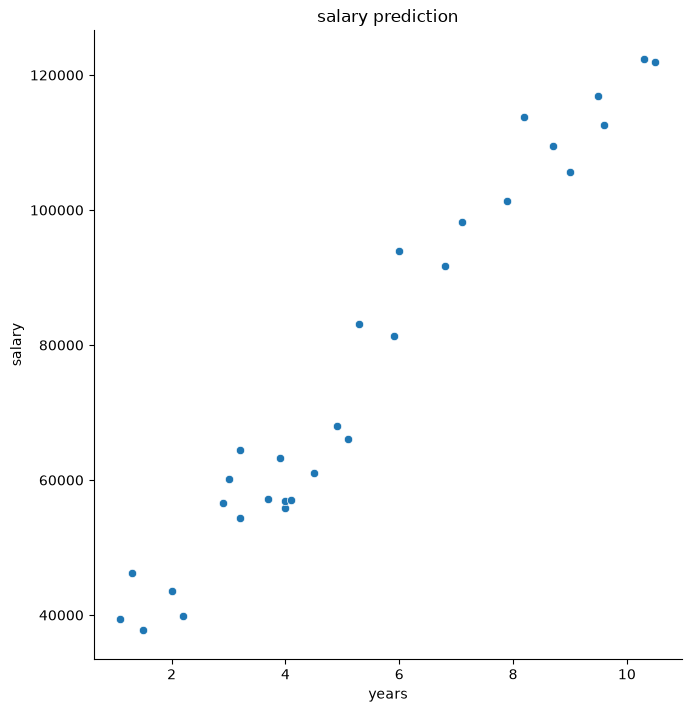

In [10]:
plt.figure(figsize=(3,3))
sns.pairplot(data,x_vars=["YearsExperience"],y_vars=["Salary"],size=7,kind="scatter")
plt.xlabel("years")
plt.ylabel("salary")
plt.title("salary prediction")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures


In [13]:
X = data.iloc[:,:-1]
y = data.iloc[:,1]

X_train , X_test , y_train , y_test = train_test_split(X,y,train_size=0.8,random_state = 10)

In [38]:
poly = PolynomialFeatures(degree=3)
x_poly_train = poly.fit_transform(X_train)
x_poly_test = poly.transform(X_test)
poly_model = LinearRegression()
poly_model.fit(x_poly_train,y_train)
y_poly_pred_train =  poly_model.predict(x_poly_train)
y_poly_pred_test =  poly_model.predict(x_poly_test)

In [39]:
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_range_poly = poly.transform(x_range)
y_range_pred = poly_model.predict(x_range_poly)

c:\Users\shahd\Desktop\DEPI_AI\DEPI-AMIT-R5-AI\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


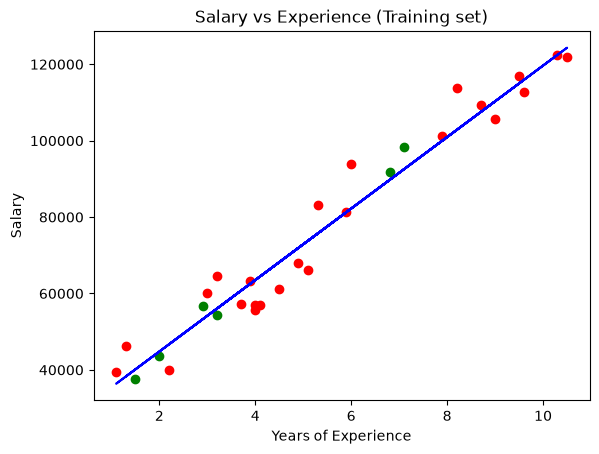

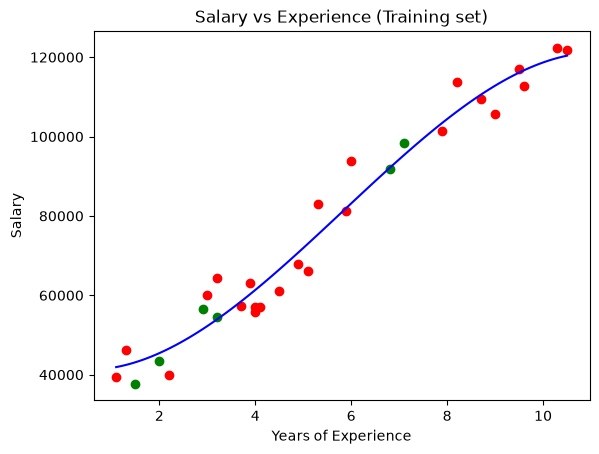

In [40]:
my_model = LinearRegression()
my_model.fit(X_train,y_train)
plt.scatter(X_train,y_train, color = "r" , label = "Actual Data")
plt.scatter(X_test,y_test, color = "green" , label = "Test Data")
plt.plot(X_train, my_model.predict(X_train), color = "blue", label = "Linear Regression")
plt.title("Salary vs Experience (Training set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()



plt.scatter(X_train,y_train, color = "r" , label = "Actual Data")
plt.scatter(X_test,y_test, color = "green" , label = "Test Data")
plt.plot(x_range, y_range_pred, color = "blue", label = "Linear Regression")
plt.title("Salary vs Experience (Training set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()
